In [10]:
# import libraries and devices
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


In [11]:
# CIFAR‑10 Dataset + DataLoader
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

train_data = datasets.CIFAR10(root=".", train=True, download=True,
                              transform=train_transform)
test_data  = datasets.CIFAR10(root=".", train=False, download=True,
                              transform=test_transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False, num_workers=2)

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # -----------------------------
        # Feature Extractor (Conv Blocks)
        # -----------------------------
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=2),    # 32x32 → 16x16
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),    # 16x16 → 8x8
            nn.Dropout(0.25),
        )

        # -----------------------------
        # Classifier (MLP Head)
        # -----------------------------
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # Flatten feature maps: (64, 8, 8) → 4096
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 10)              # Output logits for 10 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
# Loss, Optimizer, Scheduler
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [14]:
# Training Loop
def train_one_epoch(model, loader):
    model.train()
    total_loss, total_acc = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = logits.argmax(1)
        acc = (preds == y).float().mean()

        total_loss += loss.item()
        total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)

In [15]:
# Evaluation Loop
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_acc = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        preds = logits.argmax(1)
        acc = (preds == y).float().mean()

        total_loss += loss.item()
        total_acc += acc.item()

    return total_loss / len(loader), total_acc / len(loader)

In [17]:
# Training Driver
train_loss_list = []
train_acc_list = []
val_loss_list = []
val_acc_list = []

EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, test_loader)

    scheduler.step()

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 01 | Train Loss: 1.6819, Train Acc: 0.3308 | Val Loss: 1.3056, Val Acc: 0.5085
Epoch 02 | Train Loss: 1.6364, Train Acc: 0.3506 | Val Loss: 1.2521, Val Acc: 0.5361
Epoch 03 | Train Loss: 1.6036, Train Acc: 0.3648 | Val Loss: 1.2665, Val Acc: 0.5276
Epoch 04 | Train Loss: 1.5180, Train Acc: 0.4074 | Val Loss: 1.1804, Val Acc: 0.5933
Epoch 05 | Train Loss: 1.4286, Train Acc: 0.4428 | Val Loss: 1.0390, Val Acc: 0.6322
Epoch 06 | Train Loss: 1.3799, Train Acc: 0.4675 | Val Loss: 0.9816, Val Acc: 0.6492
Epoch 07 | Train Loss: 1.3392, Train Acc: 0.4903 | Val Loss: 0.9828, Val Acc: 0.6520
Epoch 08 | Train Loss: 1.2855, Train Acc: 0.5148 | Val Loss: 0.9140, Val Acc: 0.6667
Epoch 09 | Train Loss: 1.2065, Train Acc: 0.5557 | Val Loss: 0.8625, Val Acc: 0.6939
Epoch 10 | Train Loss: 1.1258, Train Acc: 0.5896 | Val Loss: 0.8225, Val Acc: 0.7028
Epoch 11 | Train Loss: 1.0912, Train Acc: 0.6042 | Val Loss: 0.7954, Val Acc: 0.7145
Epoch 12 | Train Loss: 1.0527, Train Acc: 0.6222 | Val Loss: 0.77

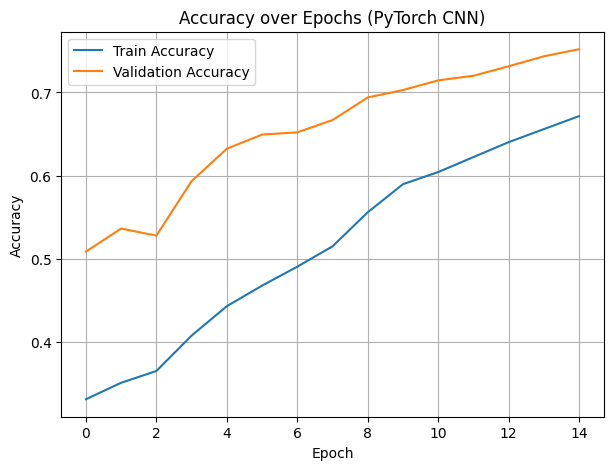

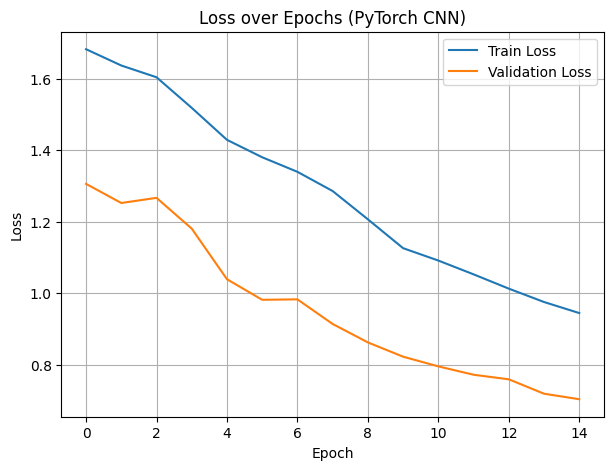

In [18]:
import matplotlib.pyplot as plt

# plot accuracy
plt.figure(figsize=(7,5))
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Validation Accuracy")
plt.title("Accuracy over Epochs (PyTorch CNN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# plot loss
plt.figure(figsize=(7,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.title("Loss over Epochs (PyTorch CNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Additional hands on practice
1. **Add a 3rd Conv Block:** Observe accuracy gain or overfitting.
2. **Replace Adam with SGD + Momentum**
    ```python
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    ```
3. **Try CosineAnnealingLR scheduler**
    ```python
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    ```
4. **Replace classifier Flatten with Global Average Pooling**
    ```python
    nn.AdaptiveAvgPool2d((1,1))
    ```
5. **Add dropout to feature extractor:** Try dropout pg. 0.1–0.3 in Conv layers.